# RQ1.1 — Temporal behavior of the token embeddings

Worked example: **FID 306 (clear cut vegetation), tile 0, cloud filter v3**.

Chosen because it is the candidate with the best joint coverage after the event
(optical 5/3/4, joint 5/1/2 over the before, event and after windows), it is
covered by a single tile, so tile and polygon coincide and the block artifact of
Section 4.1.1 does not apply, and it is one of the 346 polygons of the
quantitative analysis, so the example is traceable across research questions.

The three readings of the methodology, each for the optical, SAR and joint modes:

1. **Similarity between dates** — the $T \times T$ cosine similarity matrix
2. **Most variable dimension** — the single embedding coordinate that responds most
3. **PCA trajectory** — PC1 to PC3 projected on axes fitted once on a reference image

Every figure is exported to PDF with the same publication settings as
`croma_fid_embeddings_charlotte.ipynb`.

In [ ]:
# ── 0. working directory ────────────────────────────────────────────────
# All paths in time_series_pipeline are relative (embeddings/, data/data_csv/,
# data/data_shp/), so the notebook MUST run from the repository root. Without
# this the globs return empty and every function skips silently.
import os

REPO = os.path.expanduser("~/tropical_forest_disturbance")
os.chdir(REPO)
for d in ("embeddings", "data/data_csv", "data/data_shp"):
    assert os.path.isdir(d), f"{d} not found — wrong cwd: {os.getcwd()}"
print("cwd:", os.getcwd())

In [4]:
# ── 1. publication figure config ────────────────────────────────────────
# Same settings as croma_fid_embeddings_charlotte.ipynb, cell 50.
from pathlib import Path
import matplotlib.pyplot as plt

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "no-latex"])
except (ImportError, OSError):
    print("scienceplots not available, falling back to the default style")

TEXT_W = 160 / 25.4           # 6.30 in, text width of the document
FIGDIR = Path("qualitative/results/figures_rq1")  # copy down to the manuscript figures/ afterwards
FIGDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 12, "axes.labelsize": 12, "axes.titlesize": 11,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 10,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "savefig.bbox": "tight",
})
print("figures ->", FIGDIR.resolve())

figures -> /share/castor/home/e2406749/tropical_forest_disturbance/figures_rq1


In [5]:
# ── 2. capture the figures the pipeline draws ───────────────────────────
# The plotting helpers call plt.show() internally and neither return nor save
# their figures, so plt.show is wrapped to export each one to PDF at the
# document text width before displaying it.
#
# time_series_pipeline calls plt.show() ten times and plt.close() never, so if
# the backend does not close on show the figures pile up and every later call
# re-saves all of them. Hence the explicit close at the end.
_orig_show = plt.show
_state = {"prefix": "fig", "n": 0}


def set_prefix(prefix):
    """Name the PDFs of everything drawn from here on."""
    _state["prefix"], _state["n"] = prefix, 0


def _fit_width(fig, width=TEXT_W):
    """Scale to the text width, keeping the aspect ratio."""
    w, h = fig.get_size_inches()
    fig.set_size_inches(width, h * width / w)


def _save_and_show(*args, **kwargs):
    nums = plt.get_fignums()
    for num in nums:
        fig = plt.figure(num)
        _state["n"] += 1
        out = FIGDIR / f"{_state['prefix']}_{_state['n']:02d}.pdf"
        _fit_width(fig)
        fig.savefig(out)
        print(f"    saved {out.name}")
    _orig_show(*args, **kwargs)
    for num in nums:
        plt.close(num)


plt.show = _save_and_show


def clear_figures():
    """Wipe FIGDIR. Run before a clean pass so old PDFs do not linger."""
    n = 0
    for p in FIGDIR.glob("*.pdf"):
        p.unlink(); n += 1
    print(f"removed {n} pdf")


print("plt.show patched")

plt.show patched


In [ ]:
# ── 3. the worked example ───────────────────────────────────────────────
import time_series_pipeline as tsp
from time_series_pipeline import (CSV_TEMPLATE, _create_embeddings,
                                  _allowed_ids_for_fid, _cosine_sim_plot,
                                  _most_variable_dim, _pca_first_image,
                                  _pick_random_token, _event_date,
                                  _paths_for, _by_win)
from collections import Counter

FID, TILE, VERSION = 188, 0, "v3"
TOK_R, TOK_C = 3, 6          # frozen: drawn once at random with SEED below
SEED = 42
MODES = ("optical", "sar", "joint")

# _VERSION is a module global that appears in every plot title. The helpers
# below do not set it (only complete_analysis does), so set it here.
tsp._VERSION = VERSION

csv_path = CSV_TEMPLATE.format(version=VERSION)
_create_embeddings(FID, csv_path, 7)          # skips whatever already exists
allowed = _allowed_ids_for_fid(csv_path, FID)
S2, S1 = allowed["s2"], allowed["s1"]

print(f"fid {FID} tile {TILE} — {VERSION}")
print(f"  event date: {_event_date(FID)}")
for mode in MODES:
    c = Counter(_by_win(p) for p in _paths_for(FID, TILE, mode, S2, S1))
    print(f"  {mode:<8} bef={c['bef']:>3} evt={c['evt']:>3} aft={c['aft']:>3}")

In [ ]:
# pick (or show) the token, and see where it falls inside the polygon
#
# Drawn here rather than with _show_explicit_token, which titles the plot in pixel
# coordinates and marks a point. For the manuscript the marker has to be the token
# itself: a square of 8 by 8 pixels, labelled in token coordinates, so the figure
# and the text speak the same language.
import rasterio
import geopandas as gpd
from matplotlib.patches import Polygon as MplPolygon, Rectangle
from time_series_pipeline import _load_polygon, _first_s2_tile

clear_figures()
set_prefix(f"rq11_fid{FID}_token")

if TOK_R is None or TOK_C is None:
    TOK_R, TOK_C, *_ = _pick_random_token(FID, TILE, SEED)
    print(f"  random token -> ({TOK_R}, {TOK_C})   "
          f"# write these into TOK_R / TOK_C above to freeze the figures")
else:
    print(f"  explicit token ({TOK_R}, {TOK_C})")

gdf, poly = _load_polygon(FID)
with rasterio.open(_first_s2_tile(FID, TILE)) as src:
    poly_t = gpd.GeoSeries([poly], crs=gdf.crs).to_crs(src.crs).iloc[0]
    rgb = src.read([4, 3, 2]).transpose(1, 2, 0)
    poly_pix = [~src.transform * (x, y) for x, y in zip(*poly_t.exterior.xy)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb / 3000, vmin=0, vmax=1)
ax.add_patch(MplPolygon(poly_pix, fill=False, edgecolor="red", lw=2))
ax.add_patch(Rectangle((TOK_C * 8 - 0.5, TOK_R * 8 - 0.5), 8, 8,
                       fill=False, edgecolor="yellow", lw=2))
ax.set_title(f"FID {FID}, tile {TILE} — token ({TOK_R}, {TOK_C})", fontsize=10)
ax.set_xlabel("pixels")
ax.set_ylabel("pixels")
ax.grid(False)
fig.tight_layout()
plt.show()

## Reading 1 — similarity between dates

One $T \times T$ cosine similarity matrix per mode. Dates whose embeddings are
alike form blocks, so a disturbance should appear as a boundary between blocks at
the event date.

This is the reading that carries the **modality** axis of RQ1.1.

### cosine optical
    saved rq11_fid188_cosine_optical_01.pdf


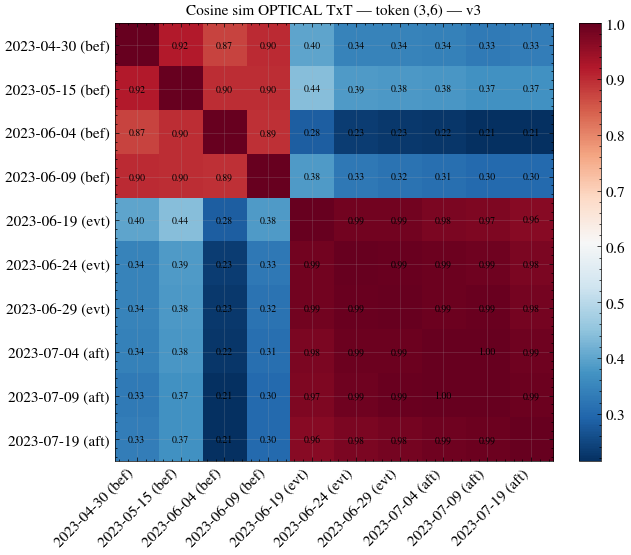

### cosine sar
    saved rq11_fid188_cosine_sar_01.pdf


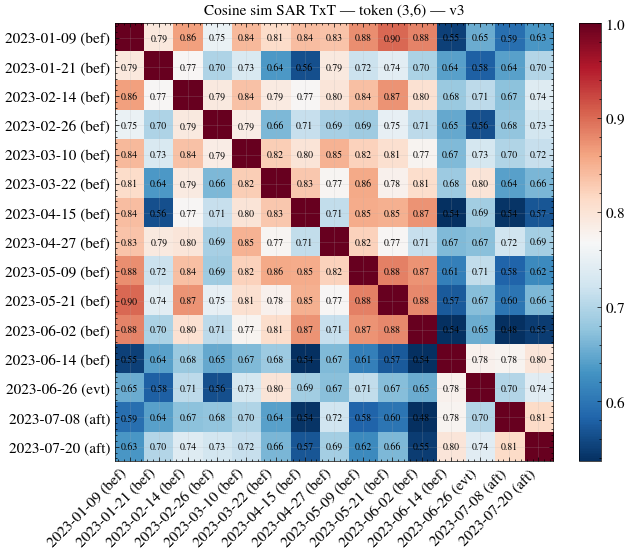

### cosine joint
    saved rq11_fid188_cosine_joint_01.pdf


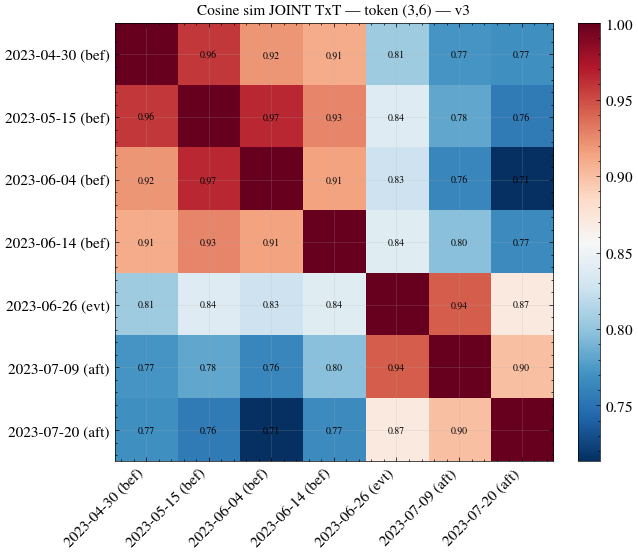

In [8]:
for mode in MODES:
    print(f"### cosine {mode}")
    set_prefix(f"rq11_fid{FID}_cosine_{mode}")
    _cosine_sim_plot(FID, TILE, TOK_R, TOK_C, mode, S2, S1)

## Reading 2 — most variable dimension

The tokens of the tile are averaged at each date, giving an array of dates by 768
dimensions; the dimension with the largest standard deviation across the series
is followed through time.

The dimension selected depends on the tile and on the mode, so these panels are
**not comparable with one another** — the quantity plotted is a different
coordinate in each. One panel is enough for the manuscript; the three are run
here only to see which mode responds.

### most variable dim optical
[optical] cube shape: (10, 15, 15, 768)
[optical] top dim: 595 (std=0.6684)
[optical] top 5 dims: [595, 414, 270, 59, 499]
[optical] top 5 scores: [0.66839998960495, 0.6315000057220459, 0.5311999917030334, 0.5293999910354614, 0.5123999714851379]
    saved rq11_fid188_mvd_optical_01.pdf


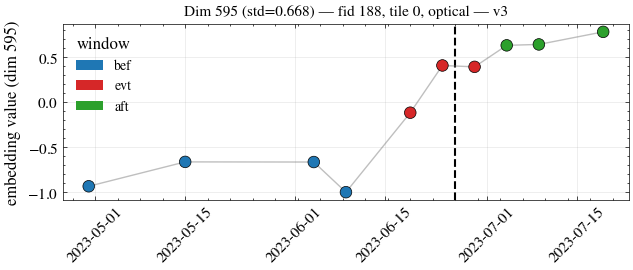

### most variable dim sar
[sar] cube shape: (15, 15, 15, 768)
[sar] top dim: 216 (std=0.4161)
[sar] top 5 dims: [216, 742, 97, 692, 729]
[sar] top 5 scores: [0.41609999537467957, 0.32510000467300415, 0.3100000023841858, 0.3073999881744385, 0.3052000105381012]
    saved rq11_fid188_mvd_sar_01.pdf


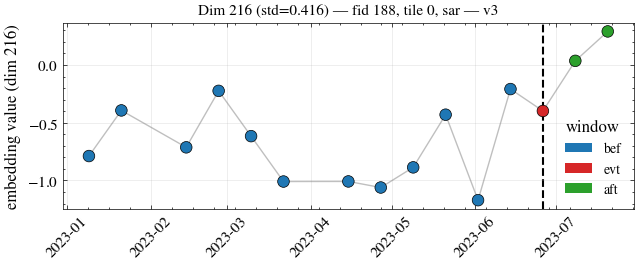

### most variable dim joint
[joint] cube shape: (7, 15, 15, 768)
[joint] top dim: 484 (std=0.6399)
[joint] top 5 dims: [484, 126, 14, 664, 712]
[joint] top 5 scores: [0.6399000287055969, 0.5936999917030334, 0.4171999990940094, 0.4162999987602234, 0.4146000146865845]
    saved rq11_fid188_mvd_joint_01.pdf


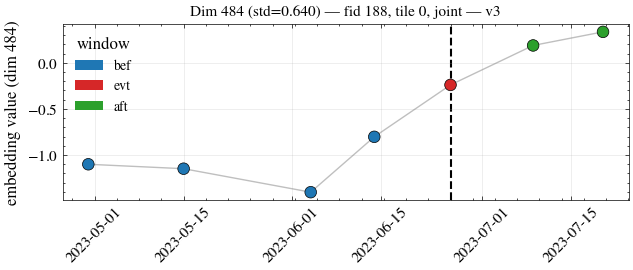

In [9]:
for mode in MODES:
    print(f"### most variable dim {mode}")
    set_prefix(f"rq11_fid{FID}_mvd_{mode}")
    _most_variable_dim(FID, TILE, mode, S2, S1)

## Reading 3 — PCA trajectory, PC1 to PC3

PCA of three components, fitted once on a single reference image (the earliest
Sentinel-2 date common to the three cloud filters) using its 225 tokens as
samples. The token series is projected onto those fixed axes.

`_pca_first_image` draws two figures per mode: `_01` is PC1 alone, `_02` is
**PC1 to PC3 together with the variance each explains** — that second one is the
figure for the manuscript.

The axes are fitted per mode, so PC1 in optical and PC1 in joint are different
axes: only the shape of the trajectory is comparable between modes, never the
values. State this in the caption.

### PCA optical
[optical] cube shape: (10, 15, 15, 768)
20230430
[optical] PCA base = 20230430T142719_20230430T142714_T20LNR (common S2 date 20230430)
[optical] PCA on first image (225 tokens) — EVR=[0.24799999594688416, 0.08900000154972076, 0.07500000298023224]
    saved rq11_fid188_pca_optical_01.pdf


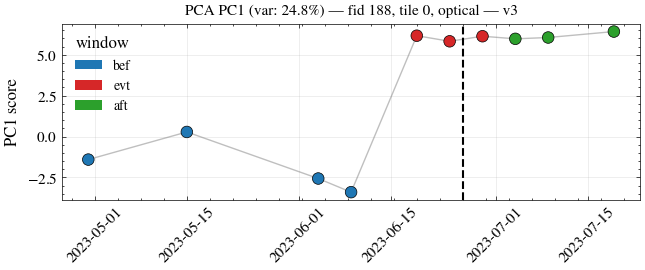

    saved rq11_fid188_pca_optical_02.pdf


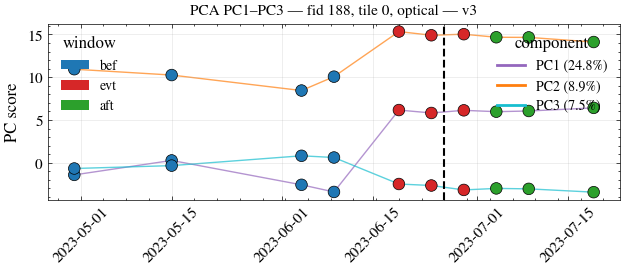

### PCA sar
[sar] cube shape: (15, 15, 15, 768)
20230430
[sar] PCA base = S1A_IW_GRDH_1SDV_20230509T094912_20230509T094937_048455_05D42C_BB80 (common S2 date 20230430)
[sar] PCA on first image (225 tokens) — EVR=[0.15000000596046448, 0.10199999809265137, 0.08100000023841858]
    saved rq11_fid188_pca_sar_01.pdf


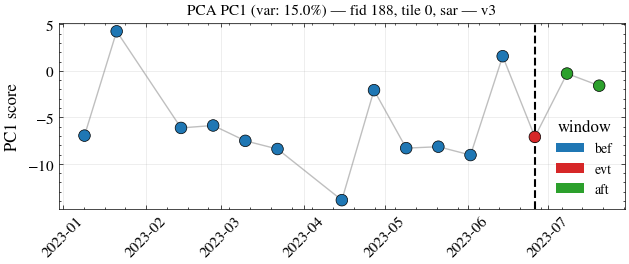

    saved rq11_fid188_pca_sar_02.pdf


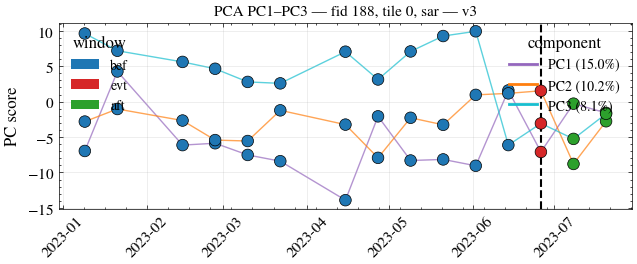

### PCA joint
[joint] cube shape: (7, 15, 15, 768)
20230430
[joint] PCA base = 20230430T142719_20230430T142714_T20LNR__S1A_IW_GRDH_1SDV_20230427T094911_20230427T094936_048280_05CE51_9F1D (common S2 date 20230430)
[joint] PCA on first image (225 tokens) — EVR=[0.24500000476837158, 0.10300000011920929, 0.06800000369548798]
    saved rq11_fid188_pca_joint_01.pdf


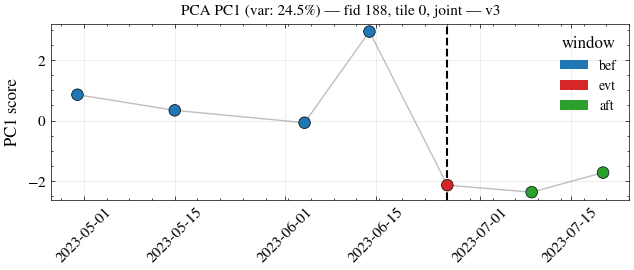

    saved rq11_fid188_pca_joint_02.pdf


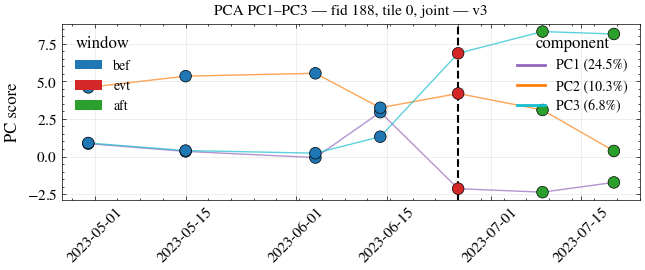

In [10]:
for mode in MODES:
    print(f"### PCA {mode}")
    set_prefix(f"rq11_fid{FID}_pca_{mode}")
    _pca_first_image(FID, TILE, TOK_R, TOK_C, mode, S2, S1)

## RQ1.2 — cloud filter comparison

The same token read under v1, v2 and v3, so the only quantity differing between
the panels is which dates survive.

`compare_versions_mvd` is a diagnostic, not a figure: it is born at 18 by 12
inches with a three by three grid, and scaled to the text width it is
unreadable. The methodology reports only the PCA, so the function below draws
exactly that, one panel per filter at text width, with a shared y axis so the
three panels are directly comparable and the date count of each is in its title.

### filters optical
20230430
    saved rq12_filters_fid188_optical_01.pdf


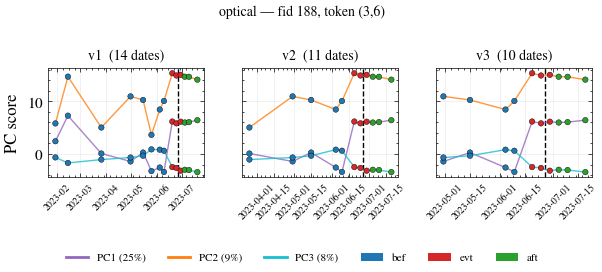

### filters sar
20230430
    saved rq12_filters_fid188_sar_01.pdf


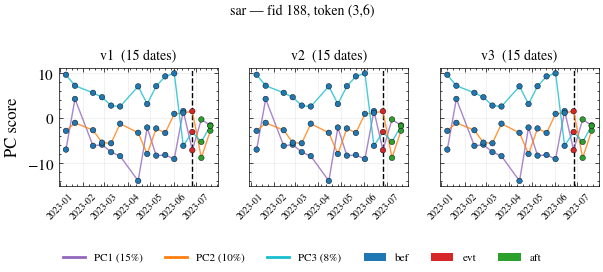

### filters joint
20230430
    saved rq12_filters_fid188_joint_01.pdf


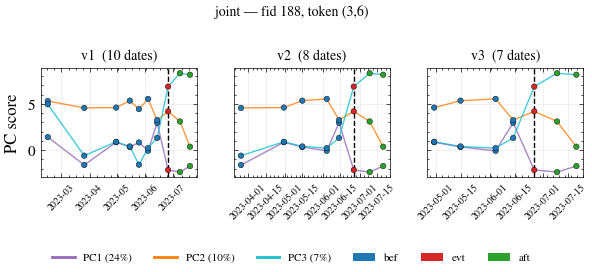

In [11]:
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from time_series_pipeline import WIN_COLORS, _fit_common_base_pca, _by_date_any

PC_COLORS = ["tab:purple", "tab:orange", "tab:cyan"]


def pca_versions_row(fid, tile, tok_r, tok_c, modality,
                     versions=("v1", "v2", "v3"), nc=3):
    """PC1 to PC3 of one token under each cloud filter, one panel per filter.

    The PCA is fitted once on the common base image, so the panels share their
    axes and the only quantity differing between them is which dates survive.
    """
    base = _fit_common_base_pca(fid, tile, modality, nc)
    if base is None:
        print(f"[{modality}] no common-S2 base image")
        return
    pca, evr = base[0], base[0].explained_variance_ratio_
    evt = _event_date(fid)

    fig, axes = plt.subplots(1, len(versions), figsize=(TEXT_W, TEXT_W * 0.38),
                             sharey=True)
    axes = np.atleast_1d(axes)
    for ax, version in zip(axes, versions):
        allowed = _allowed_ids_for_fid(CSV_TEMPLATE.format(version=version), fid)
        paths = _paths_for(fid, tile, modality, allowed["s2"], allowed["s1"])
        if not paths:
            ax.set_title(f"{version}: no data", fontsize=9)
            ax.axis("off")
            continue
        cube = np.stack([np.load(p) for p in paths])
        scores = pca.transform(cube[:, tok_r, tok_c, :])
        dates = pd.to_datetime([_by_date_any(p)[:8] for p in paths])
        colors = [WIN_COLORS[_by_win(p)] for p in paths]
        for k in range(nc):
            ax.plot(dates, scores[:, k], "-", color=PC_COLORS[k], alpha=0.8, lw=1.0)
            ax.scatter(dates, scores[:, k], c=colors, s=16,
                       edgecolors="black", linewidths=0.3, zorder=3)
        if evt is not None:
            ax.axvline(evt, color="black", ls="--", lw=1.0, zorder=0)
        ax.set_title(f"{version}  ({len(paths)} dates)", fontsize=10)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("PC score")
    handles = [plt.Line2D([0], [0], color=PC_COLORS[k], lw=2,
                          label=f"PC{k+1} ({evr[k]:.0%})") for k in range(nc)]
    handles += [Patch(facecolor=c, label=w) for w, c in WIN_COLORS.items()]
    fig.legend(handles=handles, ncol=6, fontsize=8, loc="lower center",
               bbox_to_anchor=(0.5, -0.14), frameon=False)
    fig.suptitle(f"{modality} — fid {fid}, token ({tok_r},{tok_c})", fontsize=10)
    fig.tight_layout()
    plt.show()


for mode in MODES:
    print(f"### filters {mode}")
    set_prefix(f"rq12_filters_fid{FID}_{mode}")
    pca_versions_row(FID, TILE, TOK_R, TOK_C, mode)

## Notes

- **Freeze the token.** Run once with `TOK_R = TOK_C = None`, read the coordinates
  printed above, write them into the definition cell and re run. Otherwise the
  figures depend on the seed.
- **Watch the joint panels.** Under v3 this polygon has two dates in the after
  window in joint mode, against four in optical, and that is the best joint
  coverage among the candidates. With two points after the event the joint
  trajectory supports a weaker claim than the optical one. Say so in the text
  rather than reading it as if it were the same evidence.
- **RQ1.1 also asks about disturbance types.** This notebook covers the modality
  axis on one polygon. The type axis needs one more figure: PC1 for one polygon
  per class, six small panels. Without it, half of RQ1.1 goes unanswered.
- Copy the PDFs to `manuscript_tropical_forest_disturbance/figures/` and rename
  the ones that make it into the chapter.